# ML4NLP1

## Starting Point for Exercise 1, part I

This notebook is supposed to serve as a starting point and/or inspiration when starting exercise 1, part I.

One of the goals of this exercise is to get you acquainted with sklearn and related libraries like pandas and numpy. You will probably need to consult the documentation of those libraries:
- sklearn: [Documentation](https://scikit-learn.org/stable/user_guide.html)
- Pandas: [Documentation](https://pandas.pydata.org/docs/#)
- NumPy: [Documentation](https://numpy.org/doc/)
- SHAP: [Documentation](https://shap.readthedocs.io/en/latest/index.html)

## Task Description

Follow the instructions in this notebook to:

1. Explore the data and create training/test splits for your experiments

2. Build a LogisticRegression classifier and design some relevant features to apply it to your data

3. Conduct hyperparameter tuning to find the optimal hyperparameters for your model

4. Explore your model's predictions and conduct an error analysis to see where the model fails

5. Conduct an interpretability analysis, investigating the model's most important features.

6. Conduct an ablation study using a subset of languages


Throughout the notebook, there are questions that you should address in your report. These are marked with 🗒❓.

☝ Note, these questions are intended to provide you with an opportunity to reflect on what it is that you are doing and the kind of challenges you might face along the way.




In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Set seed for reproducibility
np.random.seed(42)

### Loading the datasets

In [66]:
# Download dataset
!gdown 1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs # x_train
!gdown 1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6 # x_test
!gdown 1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl # y_train
!gdown 1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X # y_test

Downloading...
From: https://drive.google.com/uc?id=1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs
To: /Users/apple/Desktop/semester5/exercises/ex01/x_train.txt
100%|██████████████████████████████████████| 64.1M/64.1M [00:02<00:00, 28.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6
To: /Users/apple/Desktop/semester5/exercises/ex01/x_test.txt
100%|██████████████████████████████████████| 65.2M/65.2M [00:02<00:00, 29.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl
To: /Users/apple/Desktop/semester5/exercises/ex01/y_train.txt
100%|████████████████████████████████████████| 480k/480k [00:00<00:00, 7.91MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X
To: /Users/apple/Desktop/semester5/exercises/ex01/y_test.txt
100%|████████████████████████████████████████| 480k/480k [00:00<00:00, 4.34MB/s]


In [67]:
with open(f'x_train.txt') as f:
    x_train = f.read().splitlines()
with open(f'y_train.txt') as f:
    y_train = f.read().splitlines()
with open(f'x_test.txt') as f:
    x_test = f.read().splitlines()
with open(f'y_test.txt') as f:
    y_test = f.read().splitlines()

In [68]:
# Combine x_train and y_train into one dataframe
train_df = pd.DataFrame({'text': x_train, 'label': y_train})
# Write train_df to csv with tab as separator
train_df.to_csv('train_df.csv', index=False, sep='\t')
# Comibne x_test and y_test into one dataframe
test_df = pd.DataFrame({'text': x_test, 'label': y_test})
# Inspect the first 5 items in the train split
train_df.head()

,text,label
0,Klement Gottwaldi surnukeha palsameeriti ning ...,est
1,"Sebes, Joseph; Pereira Thomas (1961) (på eng)....",swe
2,भारतीय स्वातन्त्र्य आन्दोलन राष्ट्रीय एवम क्षे...,mai
3,"Après lo cort periòde d'establiment a Basilèa,...",oci
4,ถนนเจริญกรุง (อักษรโรมัน: Thanon Charoen Krung...,tha


In [69]:
# Get list of all labels
labels = train_df['label'].unique().tolist()
print(labels)

['est', 'swe', 'mai', 'oci', 'tha', 'orm', 'lim', 'guj', 'pnb', 'zea', 'krc', 'hat', 'pcd', 'tam', 'vie', 'pan', 'szl', 'ckb', 'fur', 'wuu', 'arz', 'ton', 'eus', 'map-bms', 'glk', 'nld', 'bod', 'jpn', 'arg', 'srd', 'ext', 'sin', 'kur', 'che', 'tuk', 'pag', 'tur', 'als', 'koi', 'lat', 'urd', 'tat', 'bxr', 'ind', 'kir', 'zh-yue', 'dan', 'por', 'fra', 'ori', 'nob', 'jbo', 'kok', 'amh', 'khm', 'hbs', 'slv', 'bos', 'tet', 'zho', 'kor', 'sah', 'rup', 'ast', 'wol', 'bul', 'gla', 'msa', 'crh', 'lug', 'sun', 'bre', 'mon', 'nep', 'ibo', 'cdo', 'asm', 'grn', 'hin', 'mar', 'lin', 'ile', 'lmo', 'mya', 'ilo', 'csb', 'tyv', 'gle', 'nan', 'jam', 'scn', 'be-tarask', 'diq', 'cor', 'fao', 'mlg', 'yid', 'sme', 'spa', 'kbd', 'udm', 'isl', 'ksh', 'san', 'aze', 'nap', 'dsb', 'pam', 'cym', 'srp', 'stq', 'tel', 'swa', 'vls', 'mzn', 'bel', 'lad', 'ina', 'ava', 'lao', 'min', 'ita', 'nds-nl', 'oss', 'kab', 'pus', 'fin', 'snd', 'kaa', 'fas', 'cbk', 'cat', 'nci', 'mhr', 'roa-tara', 'frp', 'ron', 'new', 'bar', 'ltg'


### 1.1 Exploring the training data

📝❓Take a look at a couple of texts from different languages and answer the following questions:

1. Do you notice anything that might be challenging for the classification?
Differences in orthography—letters and punctuation—can provide useful cues.
Closely related languages (e.g., Romance pairs like Spanish/Italian) share structure and can be hard to tell apart (e.g., Spanish vs. Portuguese; Dutch vs. German).
Code-mixed text (e.g., English plus German) may confuse the classifier.
Snippet length varies; very short pieces carry less signal and are harder to classify.
2. How is the data distributed? (i.e., how many instances per label are there in the training and test set? Is it a balanced dataset?)
balanced dataset: 500 examples per label. 235 labels in total.
3. Do you think the train/test split is appropriate (i.e., is the test data representative of the training data)? If not, please rearrange the data in a more appropriate way.
We’re currently on a 50–50 split. Target is 80–20. With cross-validation, a separate dev set for hyperparameter tuning isn’t needed, so we’ll re-split accordingly.


In [70]:
# the train dataset contains 235 unique labels
# and it contains 500 items for each label
# this results in a total of 117'500 items
train_df.label.describe()

count     117500
unique       235
top          est
freq         500
Name: label, dtype: object

In [73]:
from sklearn.model_selection import train_test_split

# evaluate test/train data split
print('training data set: ', train_df.shape)
print('test data set: ', test_df.shape)

# The test data set contains the same number of items as the test data set,
# normally we use a 80% of a dataset as training data and 20% as  test data
# - here the distribution is 50%/50%.')
# let's move some test data to training sample.

training data set:  (117500, 2)
test data set:  (117500, 2)


In [88]:
# concatenate train and test data into one dataframe
# full_df = pd.concat([train_df, test_df])
# make an 80%/20% split
train_df_adjusted, test_df_adjusted = train_test_split(train_df, test_size=0.2, random_state=42)

# check new sizes
print('new training data set: ', train_df_adjusted.shape)
print('new test data set: ', test_df_adjusted.shape)

print()


new training data set:  (94000, 2)
new test data set:  (23500, 2)



### 1.2 Data preparation

Get a subset of the train/test data that includes 20 languages.
Include English, German, Dutch, Danish, Swedish, Norwegian, and Japanese, plus 13 additional languages of your choice based on the items in the list of labels.

In [75]:
import pandas as pd

# here we define twenty languages we want to use
languages = ['eng', 'deu', 'nld', 'dan', 'swe', 'nob', 'jpn', 'est', 'mai', 'oci',
                      'tha', 'lim', 'guj', 'zea', 'krc', 'hat', 'tam', 'vie', 'pan', 'ckb']

# filter train_df and test_df by selected languages
train_df_filtered = train_df[train_df['label'].isin(languages)]
test_df_filtered = test_df[test_df['label'].isin(languages)]

print(train_df_filtered.head())

# concatenate train and test data into one dataframe
full_df = pd.concat([train_df_filtered, test_df_filtered])

# make the same 80%/20% split with randome_state = 42
train_df_adjusted, test_df_adjusted = train_test_split(full_df, test_size=0.2, random_state=42)

X_train = train_df_adjusted.text.to_numpy()
X_test = test_df_adjusted.text.to_numpy()
y_train = train_df_adjusted.label.to_numpy()
y_test = test_df_adjusted.label.to_numpy()

print()
print(np.unique(y_train))

                                                text label
0  Klement Gottwaldi surnukeha palsameeriti ning ...   est
1  Sebes, Joseph; Pereira Thomas (1961) (på eng)....   swe
2  भारतीय स्वातन्त्र्य आन्दोलन राष्ट्रीय एवम क्षे...   mai
3  Après lo cort periòde d'establiment a Basilèa,...   oci
4  ถนนเจริญกรุง (อักษรโรมัน: Thanon Charoen Krung...   tha

['ckb' 'dan' 'deu' 'eng' 'est' 'guj' 'hat' 'jpn' 'krc' 'lim' 'mai' 'nld'
 'nob' 'oci' 'pan' 'swe' 'tam' 'tha' 'vie' 'zea']


In [76]:
print('X_train_subset size: ', X_train.shape)
print('y_train_subset size: ', y_train.shape)
print('X_test_subset size: ', X_test.shape)
print('y_test_subset size: ', y_test.shape)

X_train_subset size:  (16000,)
y_train_subset size:  (16000,)
X_test_subset size:  (4000,)
y_test_subset size:  (4000,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder().fit(X_train)
y_train, y_test = label_encoder.fit_transform(y_train), label_encoder.transform(y_test)
print(label_encoder.classes_)
print(y_train)
print(y_test)

['ckb' 'dan' 'deu' 'eng' 'est' 'guj' 'hat' 'jpn' 'krc' 'lim' 'mai' 'nld'
 'nob' 'oci' 'pan' 'swe' 'tam' 'tha' 'vie' 'zea']
[ 0  6 16 ... 16 10 18]
[ 7 15  8 ...  1 15 11]


### 2.1 Build a LogisticRegression classifier

To start with, we're going to build a very simple LogisticRegression classifier.
Use a `Pipeline` to chain togther a `CountVectorizer` and a `LogisticRegression` estimator. Then perform a 5-fold cross validation and report the scores of this model as a baseline.

In [79]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Define a very basic pipeline using a CountVectorizer and a LogisticRegression classifier
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # text to matrix of counts
    ('classifier', LogisticRegression(penalty="l2", C=0.1))
])

In [80]:
# cross-validation is only performed on the training split (dev-set and test-set not included)
from sklearn.model_selection import cross_validate

# cv=5, since 5-fold
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print(f"CV scores on {len(cv_scores)} folds: {cv_scores}")
print(f"Average CV score: {cv_scores.mean():.3f}")

CV scores on 5 folds: [0.9590625 0.9590625 0.96125   0.9615625 0.966875 ]
Average CV score: 0.962



### 2.2 Feature Engineering

So far, we've only considered the basic `CountVectorizer` at the word level to encode our input texts for our model.

Your task is to apply some text preprocessing and engineer some more informative features.

To do this, think about what other features might be relevant for determining the language of an input text.

Define a custom set of feature extractors and implement the necessary preprocessing steps to extract these features from strings.

Then initialise a processing pipeline that converts your input data into features that the model can take as input.

☝ Note, this step can be as involved as your heart desires, there is only one minimal requirement: you must use something more than the base `CountVectorizer`. We recommend that you take a look at the [`BaseEstimator`](https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html) and [`TransformerMixin`](https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html#transformermixin) classes from `sk-learn`, as these can be helpful for defining custom transformers.


In [ ]:
# TODO: Data cleaning/Feature engineering steps
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

class UppercaseCounter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # Returns a two-dimensional array: the count of uppercase letters in each text
        return np.array([ [sum(ch.isupper() for ch in s)] for s in X ])
    def get_feature_names_out(self, input_features=None):
        return np.array(['feat_uppercase_count'])

# TF-IDF + custom features in parallel, then LogisticRegression
pipeline = Pipeline(steps=[
    ('features', FeatureUnion(transformer_list=[
        ('tfidf_vec', TfidfVectorizer()),
        ('upper_feat', UppercaseCounter()),
    ])),
    ('lr', LogisticRegression())
])


---

### 3.1 Grid Search

Use sklearn's GridSearchCV and experiment with the following hyperparameters:
1. Penalty (Regularization)
2. Solver
3. Experiment with parameters of the Vectorizer (optional, but highly advised)

☝ Note, don't overdo it at the beginning, since runtime might go up fast!

Make sure you read through the [docs](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html#logisticregression) to get an understanding of what these parameters do.


In [ ]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# A search space equivalent to the original one (keeping the same candidates to get a consistent optimal solution)
param_grid = {
    'lr__penalty': ['l2', 'l1'],
    'lr__solver': ['liblinear', 'saga'],
    'features__tfidf_vec__max_features': [500, None],
    # To avoid saga convergence warnings, set iterations and tolerances uniformly (without changing the optimal solution selection)
    'lr__max_iter': [2000],
    'lr__tol': [1e-3],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=4,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('features',
                                        FeatureUnion(transformer_list=[('tfidf_vec',
                                                                        TfidfVectorizer()),
                                                                       ('upper_feat',
                                                                        UppercaseCounter())])),
                                       ('lr', LogisticRegression())]),
             n_jobs=4,
             param_grid={'features__tfidf_vec__max_features': [500, None],
                         'lr__max_iter': [2000], 'lr__penalty': ['l2', 'l1'],
                         'lr__solver': ['liblinear', 'saga'],
                         'lr__tol': [0.001]},
             scoring='accuracy', verbose=1)

### 3.2 Best Model Selection

After conducting our Grid Search, we should be able to identify our best model by inspecting the using the Grid Search result attribute `cv_results_`. (Hint: `cv_results_` returns a dictionay, so convert it to a Pandas Dataframe for easy inspection.)

📝❓ What were the hyperparameter combinations for your best-performing model on the test set.
Best parameters: {'features__tfidf_vec__max_features': None, 'lr__max_iter': 2000, 'lr__penalty': 'l2', 'lr__solver': 'liblinear', 'lr__tol': 0.001}
Best CV accuracy: 0.9732500857231585

📝❓ What is the advantage of grid search cross-validation?
With 5-fold cross-validation, use an 80/20 split to maximize training data. No separate dev set is needed. Training/testing across five folds boosts stability and robustness and curbs overfitting by choosing hyperparameters that perform well across folds. We can try any hyperparameter combos and keep the empirically best—no guessing.

In [84]:
# Select the best model based on the GridSearch results

cv_table = pd.DataFrame(grid.cv_results_).sort_values('rank_test_score')
print("Top configurations:\n", cv_table[['mean_test_score','std_test_score','params']].head(), "\n")

best_params = grid.best_params_
best_cv = grid.best_score_
best_model = grid.best_estimator_

print("Best parameters:", best_params)
print("Best CV accuracy:", best_cv)
print("Chosen estimator:\n", best_model)

Top configurations:
    mean_test_score  std_test_score  \
4         0.973250        0.001562   
0         0.948563        0.004053   
6         0.942688        0.002819   
2         0.942438        0.003670   
1         0.872812        0.004890   

                                              params  
4  {'features__tfidf_vec__max_features': None, 'l...  
0  {'features__tfidf_vec__max_features': 500, 'lr...  
6  {'features__tfidf_vec__max_features': None, 'l...  
2  {'features__tfidf_vec__max_features': 500, 'lr...  
1  {'features__tfidf_vec__max_features': 500, 'lr...   

Best parameters: {'features__tfidf_vec__max_features': None, 'lr__max_iter': 2000, 'lr__penalty': 'l2', 'lr__solver': 'liblinear', 'lr__tol': 0.001}
Best CV accuracy: 0.9732500857231585
Chosen estimator:
 Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('tfidf_vec',
                                                 TfidfVectorizer()),
                                                ('upp

In [ ]:
# define the best model explicitely as pipeline for future use
pipeline = Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('tfidf', TfidfVectorizer()),
                                                ('uppercase_count',
                                                 UpperCaseExtractor())])),
                ('classifier', LogisticRegression(solver='liblinear'))])

## 3.3 Model Evaluation

Once you have identified your best model, use it to predict the languages of texts in the test split.

📝❓ According to standard metrics (e.g. Accurracy, Precision, Recall and F1), how well does your model perform on the heldout test set?


In [85]:
# Evaluate the model by inspecting the predictions on the heldout test set
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print(f"Accuracy: {acc:.3f} | Macro Precision: {macro_p:.3f} | Macro Recall: {macro_r:.3f} | Macro F1: {macro_f1:.3f}\n")
print("Per-class report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=3))

Accuracy: 0.978 | Macro Precision: 0.980 | Macro Recall: 0.978 | Macro F1: 0.978

Per-class report:

              precision    recall  f1-score   support

         ckb      1.000     0.990     0.995       204
         dan      0.989     0.954     0.971       194
         deu      0.955     0.991     0.972       214
         eng      0.859     0.986     0.918       217
         est      0.969     0.954     0.962       197
         guj      1.000     0.930     0.964       200
         hat      1.000     0.980     0.990       199
         jpn      0.909     0.969     0.938       196
         krc      1.000     0.986     0.993       211
         lim      0.995     0.990     0.993       204
         mai      1.000     0.964     0.981       192
         nld      0.974     0.979     0.977       194
         nob      0.986     0.972     0.979       213
         oci      0.962     0.986     0.974       208
         pan      1.000     0.995     0.997       200
         swe      1.000     0.995 

---

### 4.1 Error Analysis

Inspect your model's predictions using a confusion matrix and provide a summary of what you find in your report.

📝❓ Where does your model do well and where does it fail?
The pronounced main diagonal indicates high per-class accuracy; off-diagonal mass is minimal, implying limited confusion with other labels and correspondingly low rates of both false positives and false negatives.

📝❓ What are some possible reasons for why it fails in these cases?
The model tends to excel on languages that are clearly distinct or use highly distinctive scripts/character sets.
It struggles with closely related languages or ones lacking strong cues—often due to feature extraction limits or the intrinsic difficulty of those pairs.

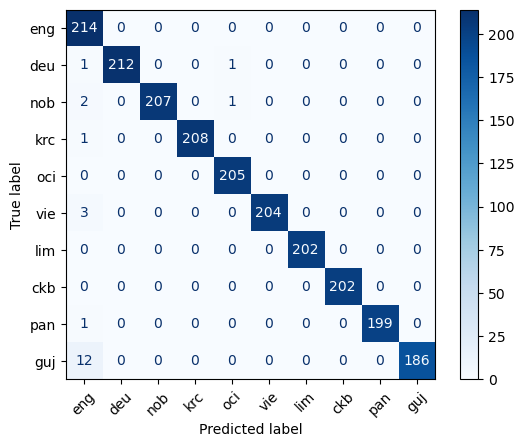

In [ ]:
# Inspect the model's predcitions on the different classes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Select the top 10 categories with the largest number of samples in the test set to draw the confusion matrix
counts = np.bincount(y_test)
top10 = np.argsort(counts)[-10:][::-1]

cm = confusion_matrix(y_test, y_pred, labels=top10)
labels_to_show = label_encoder.inverse_transform(top10)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_to_show)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')


---

### 5.1 Interpretability Analysis

Now that you have your best model, it's time to dive deep into understanding how the model makes predictions.

It is important that we can explain and visualise our models to improve task performance. Explainable models help characterise model fairness, transparency, and outcomes.

Let's try to understand what our best-performing logistic regression classification model has learned.

Inspect the 20 most important features for the languages English, Swedish, Norwegian, and Japanese. Please make sure that the features are named and human-interpretable, not things like "Feat_1". (Hint: if you have used custom feature extractors in your pipeline, you may need to adapt these to make sure that the feature names are maintained.)

📝❓ What is more important, extra features or the outputs of the vectorizer? Please discuss.

We recommend using the [SHAP library](https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/linear_models/Sentiment%20Analysis%20with%20Logistic%20Regression.html) as discussed in the tutorial. We've provided an example notebook for working with SHAP for multi-class classification in the course GitHub repo.

☝ Note, if you prefer to use another interpretability tool, we will accept answers from any explanation library/method as long as the explanations for the model weights are provided in a structured/clear way.



In [ ]:
!pip install --upgrade shap

import shap

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('tfidf', TfidfVectorizer()),
                                                ('uppercase_count',
                                                 UpperCaseExtractor())])),
                ('classifier', LogisticRegression(solver='liblinear'))])

In [ ]:
print()
print('Pipeline')
pipeline

In [ ]:
# install font to display japanese characters
!apt-get install fonts-noto-cjk -y
!rm -rf ~/.cache/matplotlib
!fc-list | grep "Noto"


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
/root/.fonts/NotoSansCJK.ttc: Noto Sans CJK JP,Noto Sans CJK JP Light:style=Light,Regular
/root/.fonts/NotoSansCJK.ttc: Noto Sans CJK JP,Noto Sans CJK JP Black:style=Black,Regular
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK SC:style=Bold
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK TC:style=Bold
/root/.fonts/NotoSansCJK.ttc: Noto Sans CJK SC,Noto Sans CJK SC Medium:style=Medium,Regular
/root/.fonts/NotoSansCJK.ttc: Noto Sans Mono CJK JP,Noto Sans Mono CJK JP Regular:style=Regular
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK JP:style=Bold
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK HK:style=Bold
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc: Noto Serif CJK K

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# List and check for Noto Sans CJK JP fonts
font_paths = fm.findSystemFonts(fontext='ttf')

for font in font_paths:
    if 'NotoSansCJK' in font:
        print("Found font:", font)
        # Add it to the font manager
        fm.fontManager.addfont(font)

# Set Noto Sans CJK JP as the font
plt.rcParams['font.family'] = 'Noto Sans CJK JP'

Found font: /root/.fonts/NotoSansCJK.ttc
Found font: /usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc
Found font: /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc


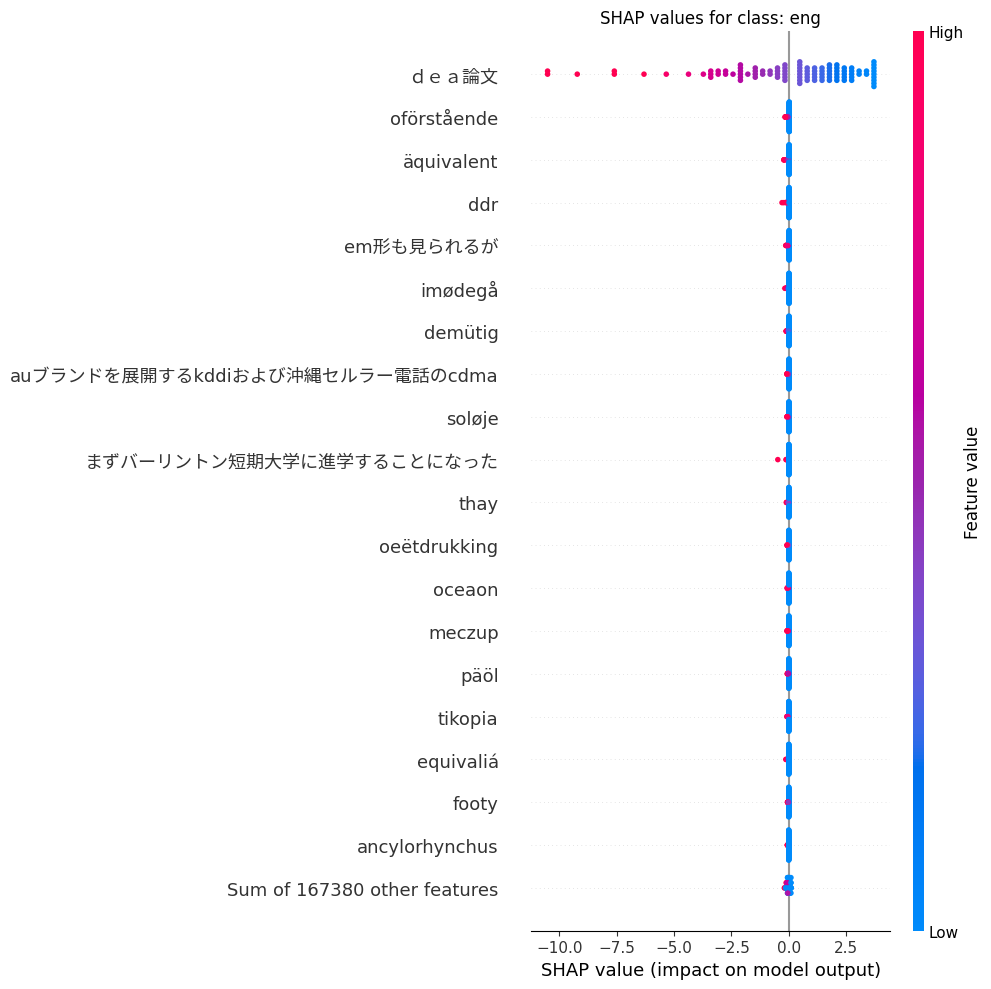

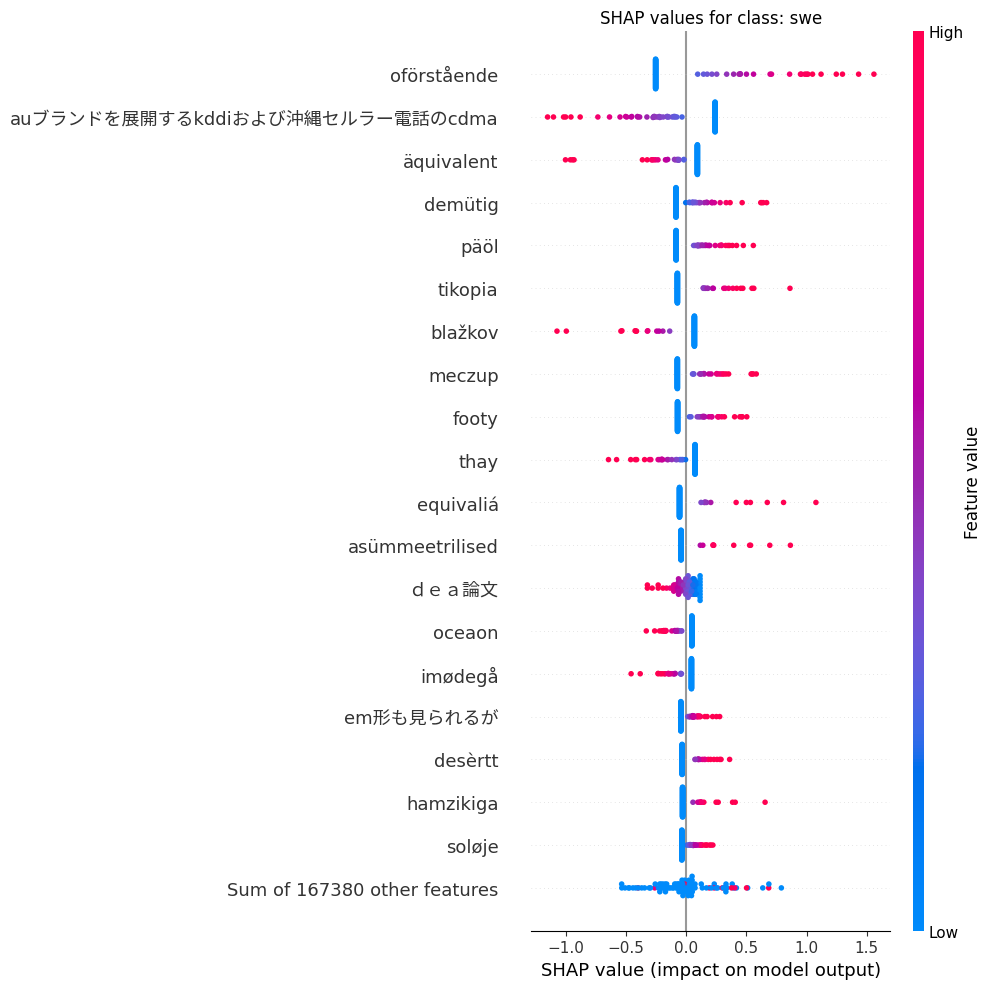

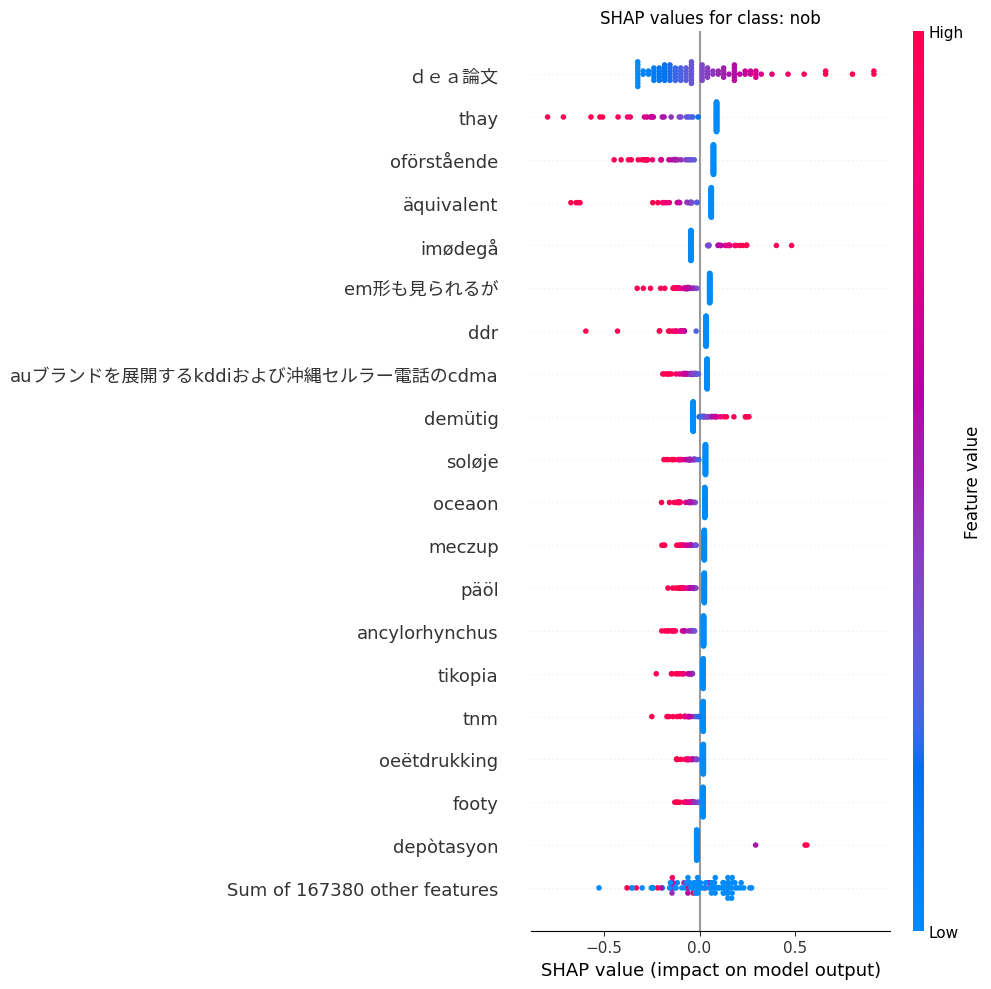

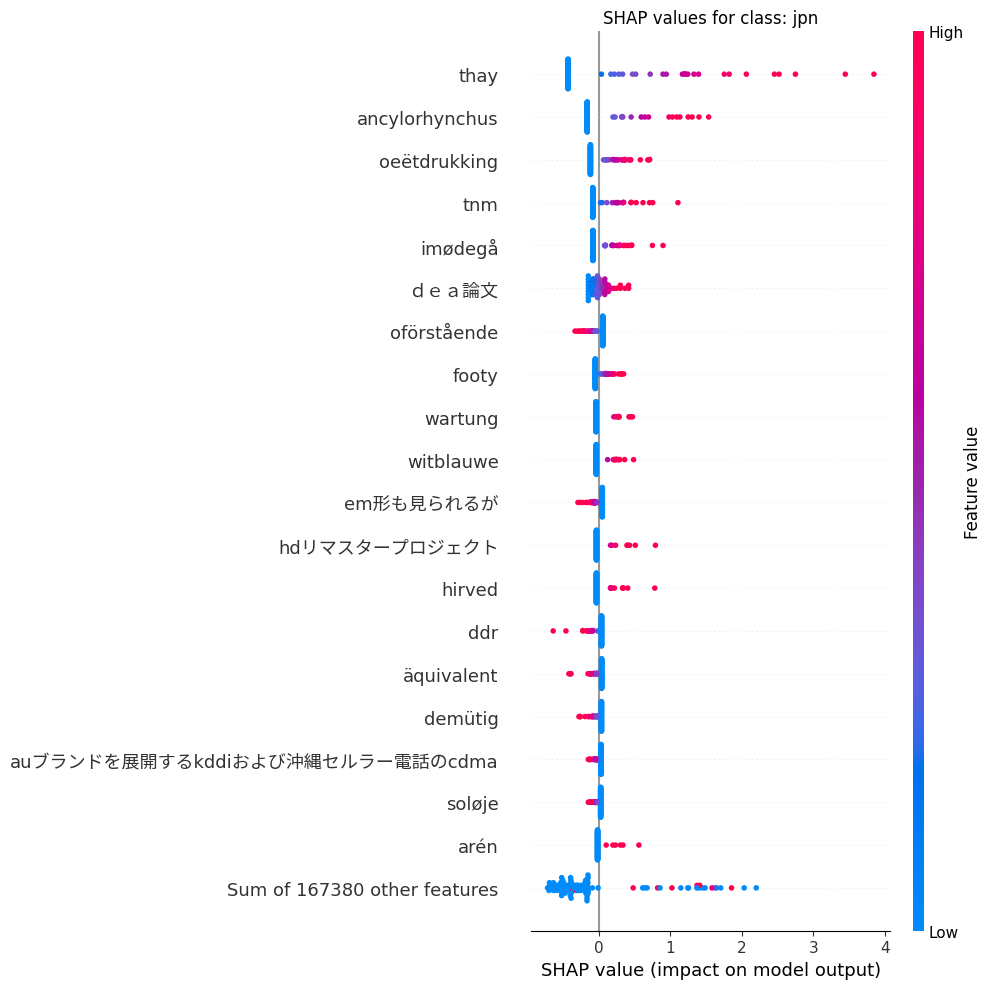

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt

languages = ['eng', 'swe', 'nob', 'jpn']

test_df_filtered = test_df[test_df['label'].isin(languages)]

X_test_filtered = test_df_filtered.text.to_numpy()
y_test_filtered = test_df_filtered.label.to_numpy()

X_test_transformed = pipeline.named_steps['features'].transform(X_test_filtered)

X_test_sampled = X_test_transformed[:100]

feature_union = pipeline.named_steps['features']

upper_case_names = ['uppercase_count']

tfidf_vectorizer = feature_union.transformer_list[0][1]
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

combined_feature_names = np.concatenate((upper_case_names, tfidf_feature_names))

explainer = shap.Explainer(
    pipeline.named_steps['classifier'],
    X_test_sampled,
    feature_names=combined_feature_names
)

shap_values = explainer(X_test_sampled)

plt.rcParams['font.family'] = ['DejaVu Sans', 'Noto Sans CJK JP']

for i, lang in enumerate(languages):
    figsize = (10, 10)
    plt.figure(figsize=figsize)

    shap.plots.beeswarm(shap_values[:, :, i], max_display=20, show=False, plot_size=figsize)
    plt.title(f"SHAP values for class: {lang}")

    plt.tight_layout()
    plt.show()


---

### 6.1 Ablation Study

Lastly, we want to conduct a small ablation study to investigate how well our model performs under different conditions.

As a first step, choose the two languages for which the classifier worked best.

Next, re-fit the best model six times, each time reducing the **length** of each instance in the training set. To do this, create a custom `TextReducer` class that you can include as a preprocessing step in your pipeline. The class should take a `max_len` argument as a hyperparameter that can be set to train the following models:

- Model 1: `max_len = None` (i.e. no truncation!)
- Model 2: `max_len = 500`
- Model 3: `max_len = 250`
- Model 4: `max_len = 150`
- Model 5: `max_len = 100`
- Model 6: `max_len = 50`

Use average accuracy over the cross validation scores for each model to measure performance for each ablation setting.

📝❓ How does the reduction of training data affect the performance of the classifier? And what could be some possible reasons for this?

In [ ]:
# Ablation study
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

class TextTruncator(BaseEstimator, TransformerMixin):
    def __init__(self, max_len=None):
        self.max_len = max_len
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if self.max_len is None:
            return X
        # Truncate to specified length
        return np.array([s[:self.max_len] for s in X])

# Ablate with two categories (e.g. German=2, English=3) to keep consistent with the original selection
two_class_ids = [2, 3]
keep = np.isin(y_train, two_class_ids)
X_bin = X_train[keep]
y_bin = y_train[keep]

lengths = [None, 500, 250, 150, 100, 50]
avg_acc = {}

for L in lengths:
    ablation_pipeline = Pipeline(steps=[
        ('truncate', TextTruncator(max_len=L)),
        ('features', FeatureUnion([
            ('tfidf_vec', TfidfVectorizer()),
            ('upper_feat', UppercaseCounter()),
        ])),
        ('lr', LogisticRegression())
    ])
    scores = cross_val_score(ablation_pipeline, X_bin, y_bin, cv=5, scoring='accuracy', n_jobs=-1)
    avg_acc[L] = float(scores.mean())
    print(f"max_len={L}: mean CV accuracy = {avg_acc[L]:.4f}")

print("Summary:", avg_acc)

max_len=None: mean CV accuracy = 0.9955
max_len=500: mean CV accuracy = 0.9955
max_len=250: mean CV accuracy = 0.9923
max_len=150: mean CV accuracy = 0.9898
max_len=100: mean CV accuracy = 0.9885
max_len=50: mean CV accuracy = 0.9739
Summary: {None: 0.9955332614313912, 500: 0.9955332614313912, 250: 0.9923424431737246, 150: 0.989792637512464, 100: 0.9885187521621456, 50: 0.9738568608697422}


📝❓ What is more important, extra features or the outputs of the vectorizer? Please discuss.


# Lab Report
## Overview
We tackle language identification as a multiclass classification problem across 235 languages. Each language contributes 500 training and 500 test samples, for a total of 117,500 instances. The model must assign every input snippet to one of these language labels.
## Approach
The test set remains untouched until the final assessment; all fitting and tuning happen on the training set via cross-validation, so no separate dev set is used.
End-to-end pipelines ensure consistent preprocessing and transparency.
Hyperparameters are tuned with GridSearch + CV. Not all solver–penalty pairings are valid; we specifically include liblinear and saga because both support L1 and L2 penalties.
After selecting the best configuration, we refit the pipeline on the full training data and evaluate once on the test set.
## Results
The final model achieves 98% accuracy on the held-out test data, handily clearing the 87% target. Coefficient analysis shows that lexical features—words indicative of multiple languages—drive performance; non-lexical engineered features such as UpperCase Count contribute relatively little.
## Notes
Model selection was compute-intensive. We reduced the search from 5 folds × 5 grids to 3 folds × 3 grids to keep runtimes reasonable.
During feature engineering, we added a custom UpperCaseExtractor to the pipeline. Since both TfidfVectorizer and UpperCaseExtractor consume raw text, we combined them in parallel with FeatureUnion at the same stage.

##Questions 📝❓

### 1.1 Exploring the training data

> 📝❓Take a look at a couple of texts from different languages and answer the following questions:

> 1. Do you notice anything that might be challenging for the classification?

*Orthographic differences—letters, scripts, punctuation—can both hinder and help: they add variability, but also make non-Latin vs. Latin scripts easier to tell apart.
Closely related languages (e.g., Spanish/Italian, Spanish/Portuguese, Dutch/German) share structure, making them harder to separate.
Code-mixed snippets (e.g., English + German) can mislead the model.
Uneven snippet length matters: shorter text carries less signal and is tougher to classify.*

> 2. How is the data distributed? (i.e., how many instances per label are there in the training and test set? Is it a balanced dataset?)

*The dataset is class-balanced: 235 labels, each with exactly 500 samples.*

> 3. Do you think the train/test split is appropriate (i.e., is the test data representative of the training data)? If not, please rearrange the data in a more appropriate way.

*The initial partition is symmetric (50/50) due to equal cardinalities of train and test. Since common practice favors an 80/20 train–test division and k-fold CV obviates a dedicated validation set for hyperparameter selection, we adjust the split to 80/20.*

### 3.2 Best Model Selection

After conducting our Grid Search, we should be able to identify our best model by inspecting the using the Grid Search result attribute `cv_results_`. (Hint: `cv_results_` returns a dictionay, so convert it to a Pandas Dataframe for easy inspection.)

> 📝❓ What were the hyperparameter combinations for your best-performing model on the test set.

*Best parameters: {'features__tfidf_vec__max_features': None, 'lr__max_iter': 2000, 'lr__penalty': 'l2', 'lr__solver': 'liblinear', 'lr__tol': 0.001}
Best CV accuracy: 0.9732500857231585
The best-performing configuration employs L2 regularization (Ridge) and the liblinear solver; the cross-validated performance is approximately  `0.973`.*

> 📝❓ What is the advantage of grid search cross-validation?

*With 5-fold cross-validation, we use an 80/20 split to maximize training data—no separate dev set is required. Training/testing across folds improves stability and robustness, reduces overfitting via cross-fold hyperparameter selection, and lets us try any hyperparameter mix and keep the empirically best.*

### 3.3 Model Evaluation

> 📝❓ According to standard metrics (e.g. Accurracy, Precision, Recall and F1), how well does your model perform on the heldout test set?

*Evaluation on the held-out test partition yields 0.978 accuracy, 0.980 precision, 0.978 recall, and an F1 of 0.978. Accuracy denotes the proportion of correct predictions, whereas precision quantifies the fraction of predicted positives that are truly positive—higher values imply a lower false-positive rate. These figures indicate strong generalization.*

### 4.1 Error Analysis

Inspect your model's predictions using a confusion matrix and provide a summary of what you find in your report.

> 📝❓ Where does your model do well and where does it fail?

![Confusion Matrix](/content/confusion_matrix.png)

*A pronounced main diagonal in the confusion matrix suggests strong performance for those classes, with minimal off-diagonal mass and consequently low false-positive and false-negative rates. Nonetheless, there is a tendency to predict English, plausibly due to loanwords or code-switching. Notably, Gujarati exhibits elevated confusion: twelve Gujarati instances are classified as English.*

> 📝❓ What are some possible reasons for why it fails in these cases?

*The model excels on clearly distinct languages or those with unique scripts.
It struggles with closely related pairs or languages lacking strong cues—partly due to feature-extraction limits and inherent pairwise ambiguity.
Some texts are mislabeled as English, likely because English terms appear widely across languages.
The English–Gujarati mix-ups may be driven by heavy English borrowing in the Gujarati samples; in principle, the different scripts (Latin vs. Gujarati) should make them easy to separate.*

### 5.1 Interpretability Analysis

In the beginning we had troubles with the calculation of the SHAP values, the Jupyter Notebooks always crashed at a certain point. We then decided to use only a subset of the data for the evaluation and not all the data. After that it worked and we could generate the plots for the four different languages. With the Japanese language we first had the problem, that it did not show the Japanese characters. We managed to install a font on Google Colab that has Japanese characters. After some adjustments we were able to display the features correctly in the plot. But some features in the plot still look a bit odd, especially the Japanese features - some still have some latin characters in it which we cannot explain, why it is like this.

> 📝❓ What is more important, extra features or the outputs of the vectorizer? Please discuss.

*The SHAP visualizations report the twenty most informative features per language. Consistently, vectorizer outputs dominate the rankings, indicating that lexical signals outweigh additional engineered features. Dot coloration encodes contribution magnitude (red indicates greater impact; blue indicates lesser impact), whereas the horizontal axis conveys the sign of the effect: negative to the left of 0.0 and positive to the right, corresponding to decreased and increased class probability, respectively.*


### 6.1 Ablation Study

> 📝❓ How does the reduction of training data affect the performance of the classifier? And what could be some possible reasons for this?

*Shorter snippets hurt performance because the model gets less linguistic evidence.
With fewer training examples, it misses key patterns—especially among languages with similar structure/vocabulary—and may fail to surface features that only appear in larger samples.
Small inputs make it harder to learn complex, multi-class distinctions when classes overlap.
Less data also raises the risk of high-variance fits/overfitting by capturing noise.*




## AI Content Declaration

Portions of the content in this Jupyter notebook were generated with the assistance of an artificial intelligence model. Specifically, AI was used to assist in:

- debugging errors
- Providing explanations and clarifications for complex concepts.
- Interpreting results, including the analysis of SHAP plots and model evaluation metrics.

All outputs and interpretations were reviewed and verified for accuracy, but the user should take responsibility for the correctness and appropriateness of the code and results.

The AI model used for assistance is OpenAI's ChatGPT 4o model.
